Load packages

In [1]:
import matplotlib.pyplot as plt
import geopandas as gpd
from shapely import Polygon
import math

from compactness_metric_functions import *

import maup

import networkx as nx

from gerrychain import (GeographicPartition, Partition, Graph, MarkovChain,
                        proposals, updaters, constraints, accept, Election)
from gerrychain.proposals import recom, propose_random_flip
from functools import partial
import pandas
from gerrychain.tree import recursive_tree_part

from gerrychain.metrics import efficiency_gap, mean_median, polsby_popper, partisan_bias

import os

from gerrychain.constraints.contiguity import contiguous_components, contiguous

from gerrychain.updaters import cut_edges

from gerrychain.tree import bipartition_tree, find_balanced_edge_cuts_memoization

from gerrychain.updaters import num_spanning_trees

import numpy as np

import pandas as pd

import random

Read files

In [2]:
CON = gpd.read_file("./NC_Processed/nc_cong_adopted_2025/NCGA_CCM-2 - Shapefile/CCM-2.shp")
Precincts = gpd.read_file("./NC_Processed/output/NC_Processed_Precincts.shp")

graph = Graph.from_json("./NC_Processed/output/NC_Processed_Precincts.json")

# Compactness

Setup

In [3]:
Precincts.keys()

Index(['PRECINCTID', 'population', 'populati_1', 'G24PRERTRU', 'G24PREDHAR',
       'G24GOVDSTE', 'G24GOVRROB', 'Total', 'Hispanic', 'NH_White', 'NH_Black',
       'NH_Other', 'Total_VAP', 'Hispanic_V', 'NH_White_V', 'NH_Black_V',
       'NH_Other_V', 'COUNTYFP', 'CON', 'SLDU', 'SLDL', 'C_X', 'C_Y',
       'geometry'],
      dtype='object')

In [3]:
def polsby_popper_gdf(gdf):
    return 4*math.pi * gdf.area/(gdf.length**2)

In [13]:
def count_spanning(graph):
    laplacian = nx.laplacian_matrix(graph)
    L = np.delete(np.delete(laplacian.todense(), 0, 0), 1, 1)
    return np.linalg.slogdet(L)[1]

def county_splits(partition, df=Precincts):
    df["current"] = df["PRECINCTID"].map(partition.assignment)

    counties = sum(df.groupby("COUNTYFP")['current'].nunique()>1)
    return counties

election_names = [
    "PRE",
    "GOV"
]

num_elections = len(election_names)

election_columns = [
  ['G24PRERTRU','G24PREDHAR'],
  ['G24GOVDSTE','G24GOVRROB']
]

my_updaters = {
    "population": updaters.Tally("population", alias="population"),
    "cut_edges": cut_edges,
    "PP":polsby_popper,
    "county_splits": county_splits
}

elections = [
    Election(
        election_names[i],
        {"Democratic": election_columns[i][1], "Republican": election_columns[i][0]},
    )
    for i in range(num_elections)
]

election_updaters = {election.name: election for election in elections}
for node in graph.nodes():
    graph.nodes()[node]["non_NH_Black"] = graph.nodes()[node]["population"] - graph.nodes()[node]["NH_Black"]

my_updaters.update({"NH_Black":Election("NH_Black",{"NH_Black": "NH_Black", "non_NH_Black": "non_NH_Black"})})
my_updaters.update()

# save percentages

my_updaters.update(election_updaters)


## District-level compactness scores

In [17]:
CON_from_Precincts = Precincts.dissolve(by='CON')
SLDU_from_Precincts = Precincts.dissolve(by='SLDU')
SLDL_from_Precincts = Precincts.dissolve(by='SLDL')

In [14]:
CONPart = GeographicPartition(graph,"CON",my_updaters)
SLDUPart = GeographicPartition(graph,"SLDU",my_updaters)
SLDLPart = GeographicPartition(graph,"SLDL",my_updaters)

In [12]:
efficiency_gap(CONPart['PRE'])

-0.25611450640053

In [15]:
CONPart["NH_Black"].percents('NH_Black')

(0.22942044041576282,
 0.19229480241029692,
 0.17956793200417584,
 0.04239387124357679,
 0.3343947666604468,
 0.2090103932041959,
 0.16776705580854165,
 0.20011859792092224,
 0.19469551364130155,
 0.1695334362636302,
 0.2111577988153698,
 0.29668742389424085,
 0.38389802664664036,
 0.24333683400032827)

In [8]:
CON_from_Precincts.keys()

Index(['geometry', 'PRECINCTID', 'population', 'populati_1', 'G24PRERTRU',
       'G24PREDHAR', 'G24GOVDSTE', 'G24GOVRROB', 'Total', 'Hispanic',
       'NH_White', 'NH_Black', 'NH_Other', 'Total_VAP', 'Hispanic_V',
       'NH_White_V', 'NH_Black_V', 'NH_Other_V', 'COUNTYFP', 'SLDU', 'SLDL',
       'C_X', 'C_Y', '% Black'],
      dtype='object')

In [19]:
plans = [CON_from_Precincts,SLDU_from_Precincts,SLDL_from_Precincts]

for plan in plans: 
    plan['% Black'] = plan['NH_Black']/plan['population']
    plan['PP'] = polsby_popper_gdf(plan)
    plan['CH'] = c_hull_ratio(plan)
    plan['R'] = 0
    plan['LW'] = 0
    plan['P'] = plan.length
    for ind, row in plan.iterrows():
        plan.loc[ind,'R']=(row['geometry'].area/(math.pi * make_circle(list(row['geometry'].convex_hull.exterior.coords))[2]**2))
        
        
        outside = list(row['geometry'].convex_hull.envelope.exterior.coords)

        o_len = max([x[0] for x in outside]) - min([x[0] for x in outside])

        o_wid = max([x[1] for x in outside]) - min([x[1] for x in outside])

        lw = min(o_len/o_wid,o_wid/o_len)
        
        plan.loc[ind,'LW'] = lw

C:\Users\angel\AppData\Local\Temp\ipykernel_49620\3500956543.py:2: UserWarning: Geometry is in a geographic CRS. Results from 'area' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  return 4*math.pi * gdf.area/(gdf.length**2)
C:\Users\angel\AppData\Local\Temp\ipykernel_49620\3500956543.py:2: UserWarning: Geometry is in a geographic CRS. Results from 'length' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  return 4*math.pi * gdf.area/(gdf.length**2)
c:\Users\angel\OneDrive\Documents\Vassar\URSI 2026\NC\compactness_metric_functions.py:119: UserWarning: Geometry is in a geographic CRS. Results from 'area' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  return geo.area
C:\Users\angel\AppData\Local\Temp\ipykernel_49620\3312354582.py:11: FutureWarning: Setting an item of incompatible dtype

In [20]:
CON_from_Precincts[['% Black','PP','CH','R','LW','P']].to_csv("./NC_Stats/NC_Compactness_CON_RDH.csv")
SLDU_from_Precincts[['% Black','PP','CH','R','LW','P']].to_csv("./NC_Stats/NC_Compactness_SLDU_RDH.csv")
SLDL_from_Precincts[['% Black','PP','CH','R','LW','P']].to_csv("./NC_Stats/NC_Compactness_SLDL_RDH.csv")

## Cut Edges

In [48]:
plan_names = ["CON","SLDU","SLDL"]
rows = []

for plan_name, part in zip(
    ["CON", "SLDU", "SLDL"],
    [CONPart, SLDUPart, SLDLPart]
):
    for district, pct in enumerate(part["PRE"].percents("Democratic"), start=1):
        rows.append({
            "Plan": plan_name,
            "Election": "PRE",
            "District": district,
            "DemPct": pct
        })

    for district, pct in enumerate(part["GOV"].percents("Democratic"), start=1):
        rows.append({
            "Plan": plan_name,
            "Election": "GOV",
            "District": district,
            "DemPct": pct
        })

df_perc_dem = pd.DataFrame(rows)

df_perc_dem.to_csv("./NC_Stats/NC_Perc_Dem_RDH.csv", index=False)

In [ ]:
ideal_con_population = sum(CONPart["population"].values()) / len(CONPart)
ideal_sldu_population = sum(SLDUPart["population"].values()) / len(SLDUPart)
ideal_sldl_population = sum(SLDLPart["population"].values()) / len(SLDLPart)

proposed_plans = [CONPart, SLDUPart, SLDLPart]


clist = ['green','hotpink','orange']

In [19]:
summary = [[] for plan in proposed_plans]


for i in range(len(proposed_plans)):
    #print("Dem Seats:", plan_names[i],proposed_plans[i]['PRS'].wins("Democratic"))
    print(plan_names[i])
    
    print("Cut Edges:", plan_names[i],len(proposed_plans[i]['cut_edges']))

    summary[i].append(len(proposed_plans[i]['cut_edges']))
    
    temp = 0
    for dist in range(1,3):
        tgraph = proposed_plans[i].subgraphs[dist]
        temp += count_spanning(tgraph)


    print("Spanning trees:",plan_names[i],temp)
    summary[i].append(temp)
    print("Mean Polsby_Popper:", plan_names[i],np.mean(list(polsby_popper(proposed_plans[i]).values())))
    summary[i].append(np.mean(list(polsby_popper(proposed_plans[i]).values())))
    print("County Splits:", plan_names[i],county_splits(proposed_plans[i]))
    summary[i].append(county_splits(proposed_plans[i]))

    
    print("Mean Population Deviation",plan_names[i],np.mean([abs((x-ideal_con_population))/ideal_con_population for x in list(proposed_plans[i]['population'].values())]))
    summary[i].append(np.mean([abs((x-ideal_con_population))/ideal_con_population for x in list(proposed_plans[i]['population'].values())]))

CON
Cut Edges: CON 737
Spanning trees: CON 666.3754902082914
Mean Polsby_Popper: CON 0.25816493304163923
County Splits: CON 11
Mean Population Deviation CON 0.003155904760481561
SLDU
Cut Edges: SLDU 1415
Spanning trees: SLDU 110.66128413794635
Mean Polsby_Popper: SLDU 0.3139325806878119
County Splits: SLDU 15
Mean Population Deviation SLDU 0.7200000000000002
SLDL
Cut Edges: SLDL 2071
Spanning trees: SLDL 57.30129342889388
Mean Polsby_Popper: SLDL 0.34547510654666996
County Splits: SLDL 36
Mean Population Deviation SLDL 0.8833333333333333


In [20]:
summary_df = pd.DataFrame(summary, columns=['Cut Edges', 'Spanning Trees', 'Mean PP', 'County Splits', 'Mean Pop Deviation'], index=plan_names)
summary_df.to_csv("./NC_Stats/NC_Compactness_Summary_RDH.csv")

# Partisan Symmetry
Utilizes 2024 Data

In [22]:
#Helper functions
def plot_symmetry_with_mean_overhaul_rb(pvec,mean,xl=0,xu=1,yl=0,yu=1):
    
    n=5000
    l=len(pvec)
    pvec = np.array(sorted(pvec))
    seats = []
    votes = []
    small = pvec[0]
    large = pvec[-1]
    
    gap = large - small
    
    
    
    #mean = np.mean(pvec)
    
    lvec = pvec - mean*np.ones([1,l])
    
    
    
    for t in range(n):
        tvec = lvec + (t/n)*np.ones([1,l])
        votes.append(t/n)#votes.append(np.mean(tvec))
        seats.append(sum(sum(tvec>=.5))/l)
        
    
 
    #print(lvec,tvec,seats[400])
    
    plt.figure(figsize=(8,8) )   
    plt.plot(votes,seats,linewidth = 3,color='r')
    plt.axhline(.5,color='gray')
    plt.axvline(.5,color='gray')

    #plt.plot([.5],[.5],'ro', markersize=10)
    plt.plot([mean],[sum(pvec>=.5)/l],'r*', markersize=20)

    plt.xlabel("Dem Vote %")
    plt.ylabel("Dem Seat %")
    #plt.xticks(bn,cn, rotation=45)
    ys=[x/l for x in range(l+1)]
    zs=[str(round(float(ys), 3)) for ys in ys]
    #plt.yticks(ys,zs)
    
    plt.xlim([xl,xu])
    plt.ylim([yl,yu])

    plt.title("Seats -- Votes")
    
    

    plt.show()
    
    fvotes = [1-x for x in votes]
    fseats = [1-x for x in seats]
    
    plt.figure(figsize=(8,8) )   
    plt.plot(votes,seats,linewidth = 1,color='blue')
    plt.plot(fvotes,fseats,linewidth = 1,color='red')
    plt.axhline(.5,color='gray')
    plt.axvline(.5,color='gray')
    plt.fill_between(votes,seats,list(reversed(fseats)),color='gray')

    #plt.plot([.5],[.5],'ro', markersize=10)
    #plt.plot([mean],[sum(pvec>=.5)/l],'g*', markersize=10)

    plt.xlabel("Dem Vote %")
    plt.ylabel("Dem Seat %")
    #plt.xticks(bn,cn, rotation=45)
    ys=[x/l for x in range(l+1)]
    zs=[str(round(float(ys), 3)) for ys in ys]
    #plt.yticks(ys,zs)
    
    plt.xlim([xl,xu])
    plt.ylim([yl,yu])

    plt.title("Seats -- Votes: Symmetry Gaps")    
  

def plot_lots_symmetry_notmean(pvecs,means,xl=0,xu=1,yl=0,yu=1):
    
    n=5000
    
    ind = 0 
    
    clist = ['tab:blue','tab:orange','tab:green','tab:red','tab:purple','tab:brown',
            'tab:pink','tab:gray','tab:olive','tab:cyan','black','lime','navy','burlywood',
            'salmon','blueviolet','chocolate','yellow','fuchsia','silver']
    plt.figure(figsize=(8,8) )  
    for pvec in pvecs: 
        l=len(pvec)
        pvec = np.array(sorted(pvec))
        seats = []
        votes = []
        small = pvec[0]
        large = pvec[-1]

        gap = large - small



        mean = means[ind] #np.mean(pvec)

        lvec = pvec - mean*np.ones([1,l])



        for t in range(n):
            tvec = lvec + (t/n)*np.ones([1,l])
            votes.append(np.mean(tvec))
            seats.append(sum(sum(tvec>=.5))/l)


        bn = np.array([mean+ (.5-x) for x in pvec])


        cn=[str(round(float(bn), 3)) for bn in bn]
        bvotes=[]
        bseats=[]

        for t in range(n):
            bvotes.append(t/n)
            bseats.append(sum(bn<(t/n))/l)


        bn = np.array([mean+ (.5-x) for x in pvec])

        bvotes=[]
        bseats=[]

        for t in range(n):
            bvotes.append(t/n)
            bseats.append(sum(bn<(t/n))/l)

        dn=list(bn[:])
        for x in bn:
            dn.append(1-x)

        rseats=list(reversed(seats))


        en=[str(round(float(dn), 3)) for dn in dn]
        area=0
        for t in range(n):
            area += (1/n)*abs(seats[t]-(1-rseats[t])) 



         
        plt.plot(bvotes,bseats,linewidth = 2,color=clist[ind],label=enames[ind],alpha=.5)
        

        #plt.plot([.5],[.5],'ro', markersize=10)
        plt.plot([mean],[sum(pvec>=.5)/l],'o',color=clist[ind], markersize=8,zorder=100)
        
        ind +=1
    
    
    plt.axhline(.5,color='gray')
    plt.axvline(.5,color='gray')
    plt.xlabel("Democratic Vote Share")
    plt.ylabel("Democratic Seat Share")
    #plt.xticks(bn,cn, rotation=45)
    ys=[x/l for x in range(l+1)]
    zs=[str(round(float(ys), 3)) for ys in ys]
    #plt.yticks(ys,zs)

    plt.xlim([xl,xu])
    plt.ylim([yl,yu])
    plt.legend()

    #plt.title("Seats -- Votes")
    
    

    plt.show()

 
def declination(vals):
    """ Compute the declination of an election.
    """
    Rwin = sorted(filter(lambda x: x <= 0.5, vals))
    Dwin = sorted(filter(lambda x: x > 0.5, vals))
    # Undefined if each party does not win at least one seat
    if len(Rwin) < 1 or len(Dwin) < 1:
        return False
    theta = np.arctan((1-2*np.mean(Rwin))*len(vals)/len(Rwin))
    gamma = np.arctan((2*np.mean(Dwin)-1)*len(vals)/len(Dwin))
    # Convert to range [-1,1]
    # A little extra precision just in case.
    return 2.0*(gamma-theta)/3.1415926535 


def lopsided_wins(vals):
    Rwin = sorted(filter(lambda x: x <= 0.5, vals))
    Dwin = sorted(filter(lambda x: x > 0.5, vals))
    
    Rmargin = abs(np.mean(Rwin)-.5)*2
    Dmargin = abs(np.mean(Dwin)-.5)*2
    
    return Rmargin - Dmargin
    

In [ ]:
plan_partitions = proposed_plans
plan_part_labels = plan_names
enames = election_names

In [24]:
sorted(CONPart["PRE"].percents("Democratic"))

[0.4015134041175902,
 0.4102550692587003,
 0.4105112876315188,
 0.41316756365141794,
 0.4152301363495878,
 0.41886754221788536,
 0.42424257414722344,
 0.42972030525431776,
 0.4301783057905161,
 0.44262948889535925,
 0.4518196604772827,
 0.6714747293927874,
 0.7289525437627258,
 0.7353109186481949]

In [25]:
n_base_plans = 3

wins = [[] for i in range(n_base_plans)]
votes = [[] for i in range(n_base_plans)]
majs = [[] for i in range(n_base_plans)]
mms = [[] for i in range(n_base_plans)]
egs = [[] for i in range(n_base_plans)]
pbs =[[] for i in range(n_base_plans)]
decs = [[] for i in range(n_base_plans)]
lws = [[] for i in range(n_base_plans)]
comps = [[] for i in range(n_base_plans)]


for election in range(num_elections):
    summary = [[] for election in range(n_base_plans)]

    print(enames[election])
    #print('Votes: ', plan_partitions[0][enames[election]].percent("Democratic"))
    
    for i in range(n_base_plans):
        votes[i].append(plan_partitions[i][enames[election]].percent("Democratic"))
        summary[i].append(plan_partitions[i][enames[election]].percent("Democratic"))
        print('Votes: ', plan_partitions[i][enames[election]].percent("Democratic"))
    print('Seats')

    for i in range(n_base_plans):
        wins[i].append(plan_partitions[i][enames[election]].wins("Democratic"))
        print(plan_part_labels[i],wins[i][-1])
        summary[i].append(plan_partitions[i][enames[election]].wins("Democratic"))
    
    print("Majority?")
    for i in range(n_base_plans):
    
        if plan_partitions[i][enames[election]].percent("Democratic") > .5:
            if plan_partitions[i][enames[election]].wins("Democratic")>len(plan_partitions[i])/2:
                majs[i].append(1)
            else:
                majs[i].append(0)
        else:
            if plan_partitions[i][enames[election]].wins("Democratic")>len(plan_partitions[i])/2:
                majs[i].append(0)
            else:
                majs[i].append(1)
        print(plan_part_labels[i],majs[i][-1])
        summary[i].append(majs[i][-1])
    
    print("Mean-Median")
    for i in range(n_base_plans):
        mms[i].append(np.median(plan_partitions[i][enames[election]].percents("Democratic"))-plan_partitions[i][enames[election]].percent("Democratic"))
        print(plan_part_labels[i],mms[i][-1])
        summary[i].append(mms[i][-1])
        
    print("Partisan Bias")
    for i in range(n_base_plans):
        pbs[i].append(partisan_bias(plan_partitions[i][enames[election]]))
        print(plan_part_labels[i],pbs[i][-1])
        summary[i].append(pbs[i][-1])
    
    print("Efficiency Gap")
    for i in range(n_base_plans):
        egs[i].append(efficiency_gap(plan_partitions[i][enames[election]]))
        print(plan_part_labels[i],egs[i][-1])
        summary[i].append(egs[i][-1])
    
    
    print("Declination")
    for i in range(n_base_plans):
        decs[i].append(declination(plan_partitions[i][enames[election]].percents("Democratic")))
        print(plan_part_labels[i],decs[i][-1])
        summary[i].append(decs[i][-1])
        
    print("Lopsided Wins")
    for i in range(n_base_plans):
        lws[i].append(lopsided_wins(plan_partitions[i][enames[election]].percents("Democratic")))
        print(plan_part_labels[i],lws[i][-1])
        summary[i].append(lws[i][-1])
        
        
    print("Competitive 47-53 Districts")
    for i in range(n_base_plans):
        comps[i].append(np.sum([.47 < x <.53 for x in plan_partitions[i][enames[election]].percents("Democratic") ]))
        print(plan_part_labels[i],comps[i][-1])
        summary[i].append(comps[i][-1])
    
    df_summary = pd.DataFrame(summary, columns=['Votes', 'Seats', 'Majority', 'Mean-Median', 'Partisan Bias', 'Efficiency Gap', 'Declination', 'Lopsided Wins', 'Competitive Districts'], index=plan_part_labels)
    display(df_summary)
    #df_summary.to_csv("./NC_Stats/NC_Partisan_Summary_"+enames[election]+"_RDH.csv")
        

PRE
Votes:  0.4836617651278814
Votes:  0.4836617651278814
Votes:  0.4836617651278814
Seats
CON 3
SLDU 19
SLDL 48
Majority?
CON 1
SLDU 1
SLDL 1
Mean-Median
CON -0.05668032542711077
SLDU -0.058810160030506986
SLDL -0.03119304932765543
Partisan Bias
CON -0.2857142857142857
SLDU -0.09999999999999998
SLDL -0.07500000000000001
Efficiency Gap
CON -0.25611450640053
SLDU -0.09999312010531586
SLDL -0.08523663718590206
Declination
CON 0.5780821323049625
SLDU 0.2279335756116455
SLDL 0.18741422965829999
Lopsided Wins
CON -0.2689409771645447
SLDU -0.09790153870124951
SLDL -0.07908684739313065
Competitive 47-53 Districts
CON 0
SLDU 4
SLDL 10


,Votes,Seats,Majority,Mean-Median,Partisan Bias,Efficiency Gap,Declination,Lopsided Wins,Competitive Districts
CON,0.483662,3,1,-0.056680,-0.285714,-0.256115,0.578082,-0.268941,0
SLDU,0.483662,19,1,-0.058810,-0.100000,-0.099993,0.227934,-0.097902,4
SLDL,0.483662,48,1,-0.031193,-0.075000,-0.085237,0.187414,-0.079087,10


GOV
Votes:  0.4220722985624271
Votes:  0.4220722985624271
Votes:  0.4220722985624271
Seats
CON 1
SLDU 22
SLDL 47
Majority?
CON 1
SLDU 1
SLDL 1
Mean-Median
CON 0.059911773158872306
SLDU 0.06333737148959273
SLDL 0.025774553099227604
Partisan Bias
CON 0.2857142857142857
SLDU 0.07999999999999996
SLDL 0.06666666666666665
Efficiency Gap
CON -0.2727079115395984
SLDU 0.09317830602298376
SLDL 0.03992806954846884
Declination
CON 0.036902610644857385
SLDU -0.2114790421940438
SLDL -0.09145261171092182
Lopsided Wins
CON 0.1512464492924157
SLDU 0.26162204504797604
SLDL 0.20428819758966987
Competitive 47-53 Districts
CON 9
SLDU 14
SLDL 16


,Votes,Seats,Majority,Mean-Median,Partisan Bias,Efficiency Gap,Declination,Lopsided Wins,Competitive Districts
CON,0.422072,1,1,0.059912,0.285714,-0.272708,0.036903,0.151246,9
SLDU,0.422072,22,1,0.063337,0.080000,0.093178,-0.211479,0.261622,14
SLDL,0.422072,47,1,0.025775,0.066667,0.039928,-0.091453,0.204288,16


CON


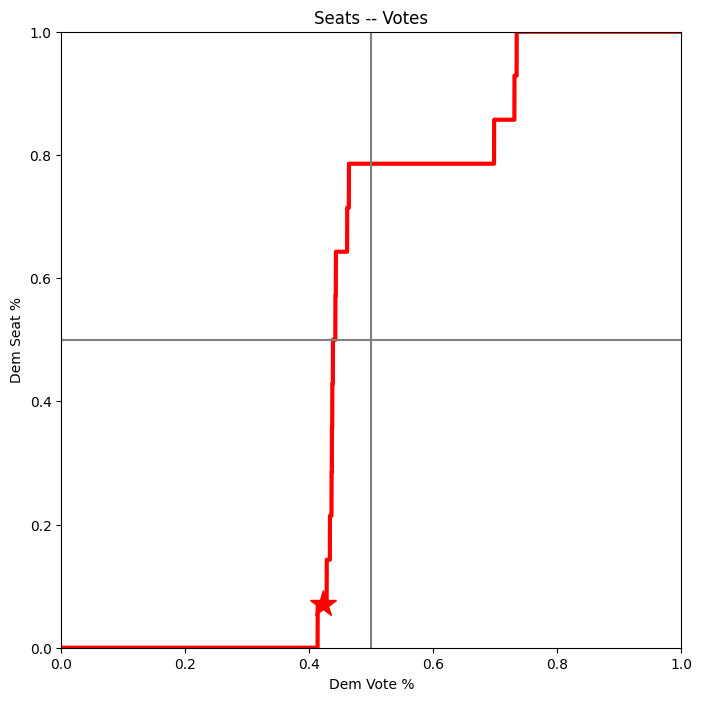

SLDU


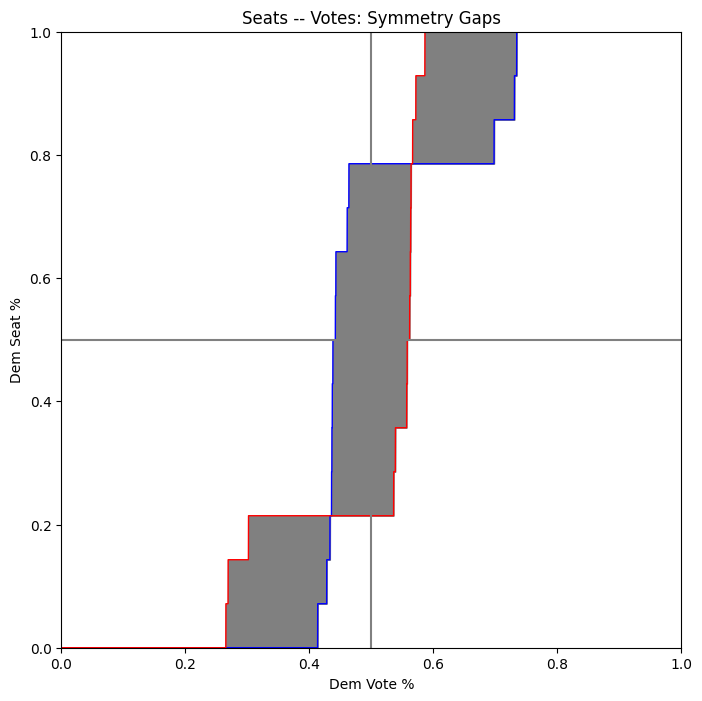

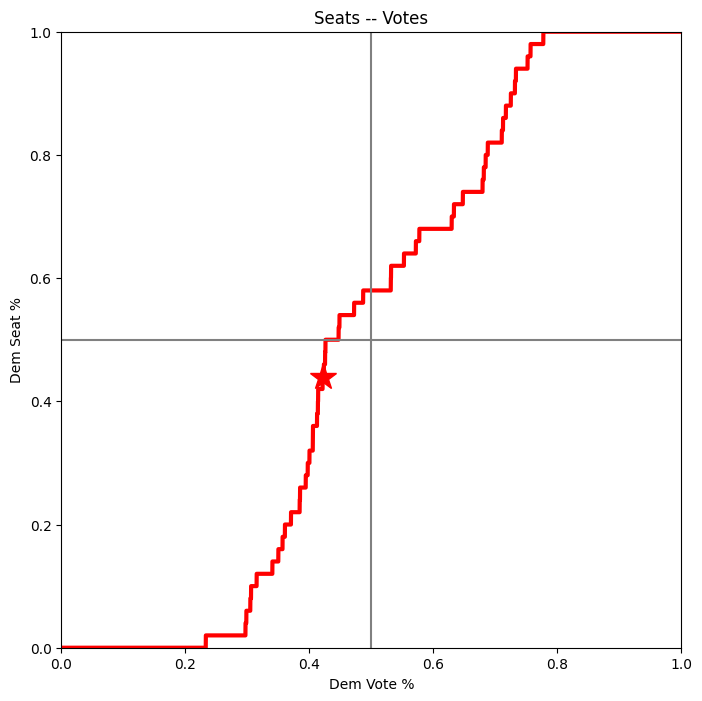

SLDL


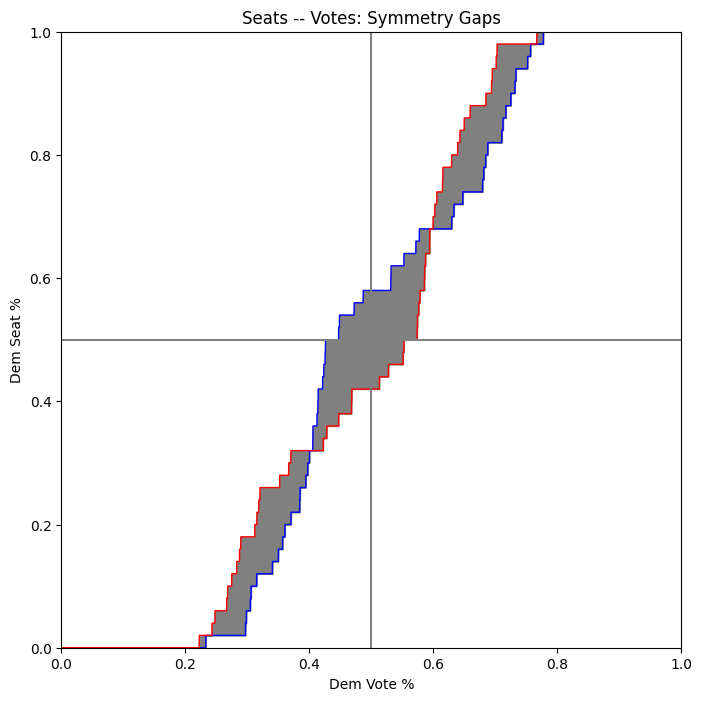

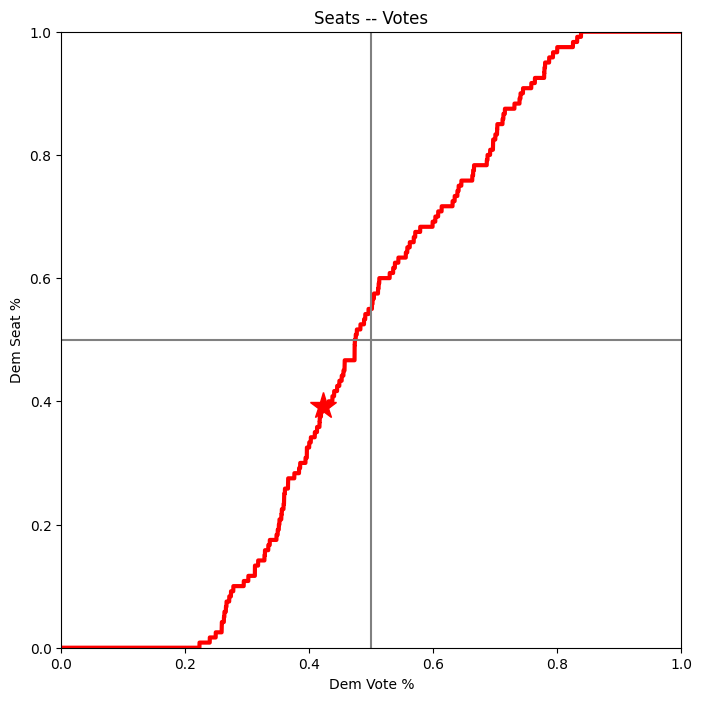

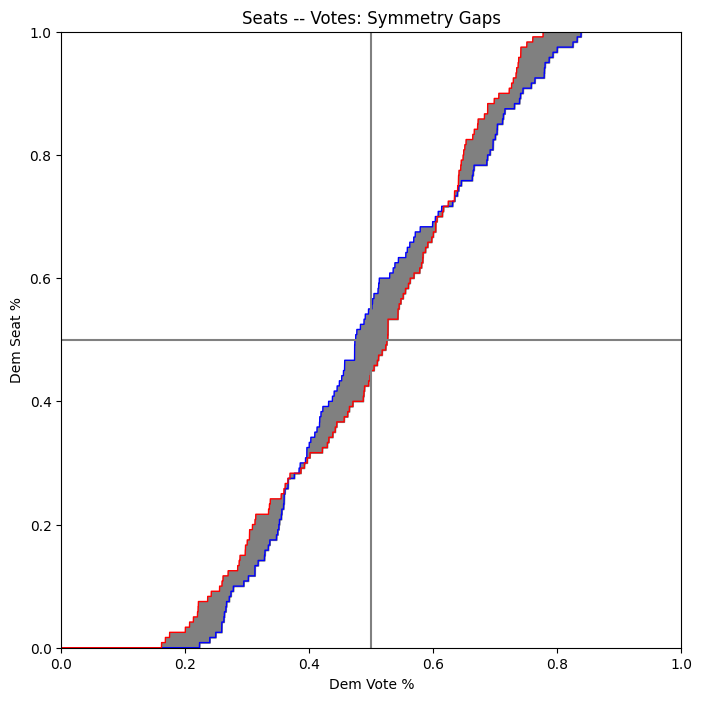

In [27]:
for i in range(n_base_plans):
    print(plan_part_labels[i])
    plot_symmetry_with_mean_overhaul_rb(sorted(plan_partitions[i]["GOV"].percents("Democratic")),plan_partitions[i]["GOV"].percent("Democratic"))